In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [52]:
df = pd.read_csv("megaGymDataset.csv")

print(df.shape)
df.head()

(2918, 9)


,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exe...,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,The banded crunch isometric hold is an exercis...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,The banded plank jack is a variation on the pl...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
3,3,Banded crunch,The banded crunch is an exercise targeting the...,Strength,Abdominals,Bands,Intermediate,NaN,NaN
4,4,Crunch,The crunch is a popular core exercise targetin...,Strength,Abdominals,Bands,Intermediate,NaN,NaN


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2918 non-null   int64  
 1   Title       2918 non-null   str    
 2   Desc        1368 non-null   str    
 3   Type        2918 non-null   str    
 4   BodyPart    2918 non-null   str    
 5   Equipment   2886 non-null   str    
 6   Level       2918 non-null   str    
 7   Rating      1031 non-null   float64
 8   RatingDesc  862 non-null    str    
dtypes: float64(1), int64(1), str(7)
memory usage: 819.1 KB


In [54]:
df.describe()

,Unnamed: 0,Rating
count,2918.000000,1031.000000
mean,1458.500000,5.919690
std,842.498368,3.584607
min,0.000000,0.000000
25%,729.250000,3.000000
50%,1458.500000,7.900000
75%,2187.750000,8.700000
max,2917.000000,9.600000


In [55]:
df.describe(include="object")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24280\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Title,Desc,Type,BodyPart,Equipment,Level,RatingDesc
count,2918,1368,2918,2918,2886,2918,862
unique,2909,1050,7,17,12,3,1
top,Band-suspended kettlebell bench press,The barbell back squat is a popular compound m...,Strength,Abdominals,Body Only,Intermediate,Average
freq,3,10,2545,662,1078,2446,862


In [56]:
df.isnull().sum()

Unnamed: 0       0
Title            0
Desc          1550
Type             0
BodyPart         0
Equipment       32
Level            0
Rating        1887
RatingDesc    2056
dtype: int64

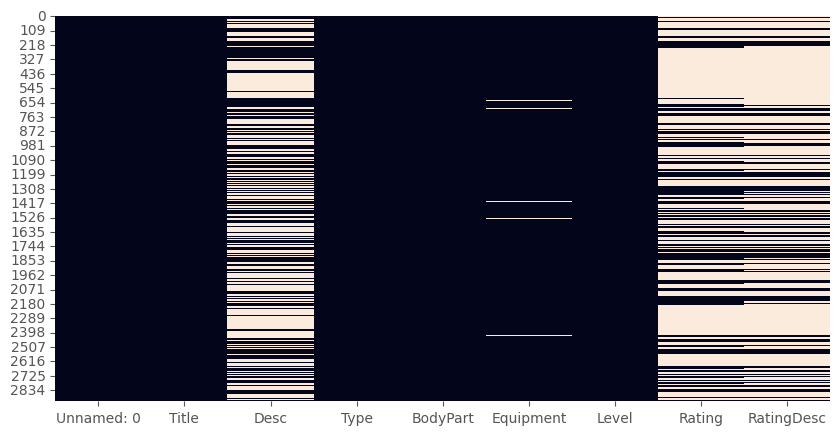

In [57]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [58]:
df["Equipment"] = df["Equipment"].fillna("Unknown")

df["Desc"] = df["Desc"].fillna("No Description")

df["Rating"] = df["Rating"].fillna(df["Rating"].mean())

df["RatingDesc"] = df["RatingDesc"].fillna("No Rating")

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.drop_duplicates(inplace=True)

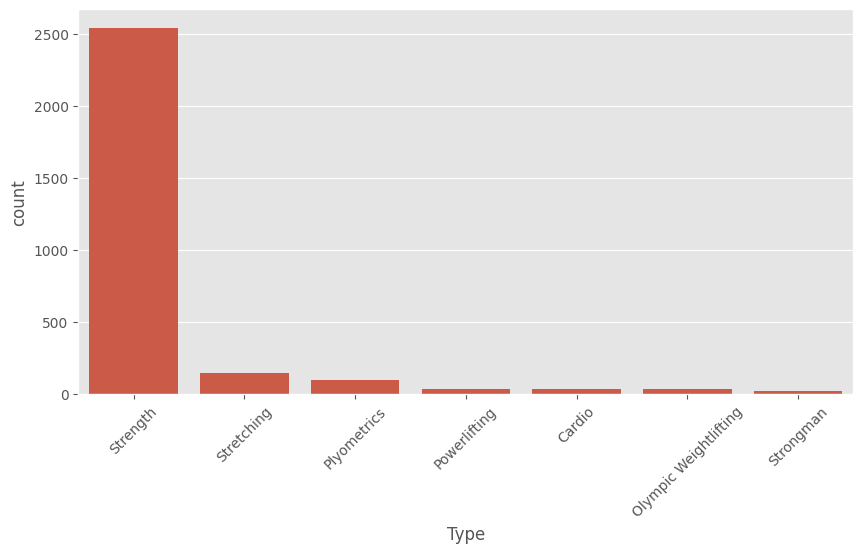

In [61]:
plt.figure(figsize=(10,5))

sns.countplot(
    x=df["Type"],
    order=df["Type"].value_counts().index
)

plt.xticks(rotation=45)
plt.show()

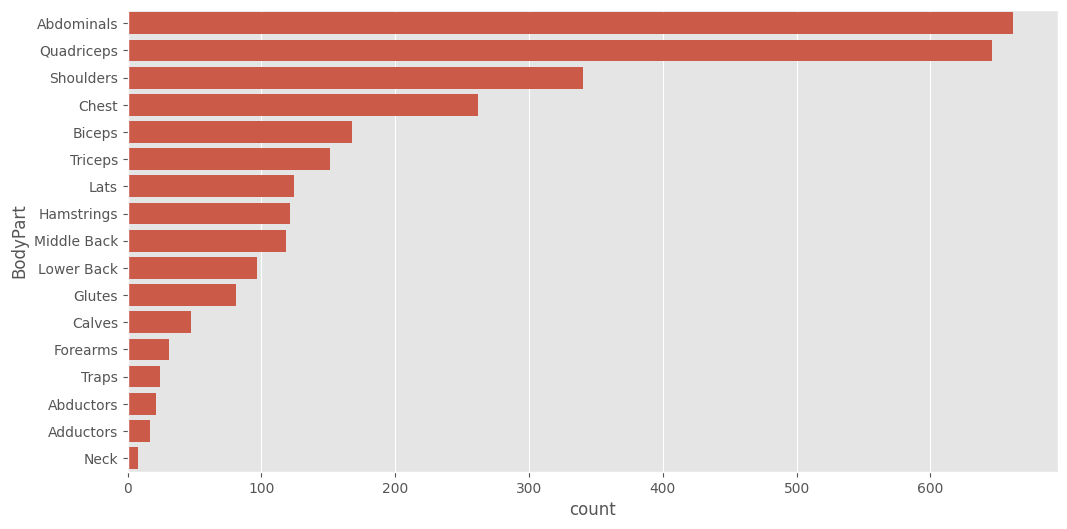

In [62]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df["BodyPart"],
    order=df["BodyPart"].value_counts().index
)

plt.show()

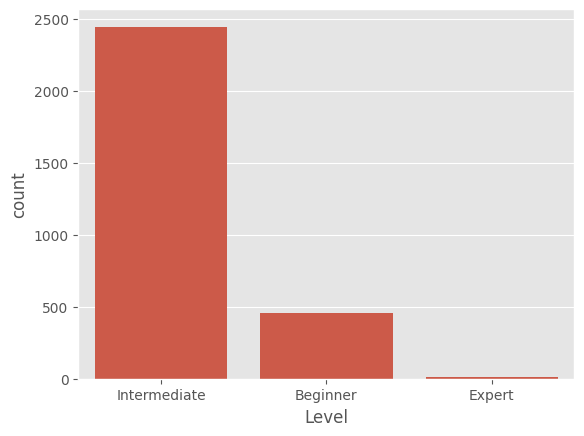

In [63]:
sns.countplot(x="Level",data=df)
plt.show()

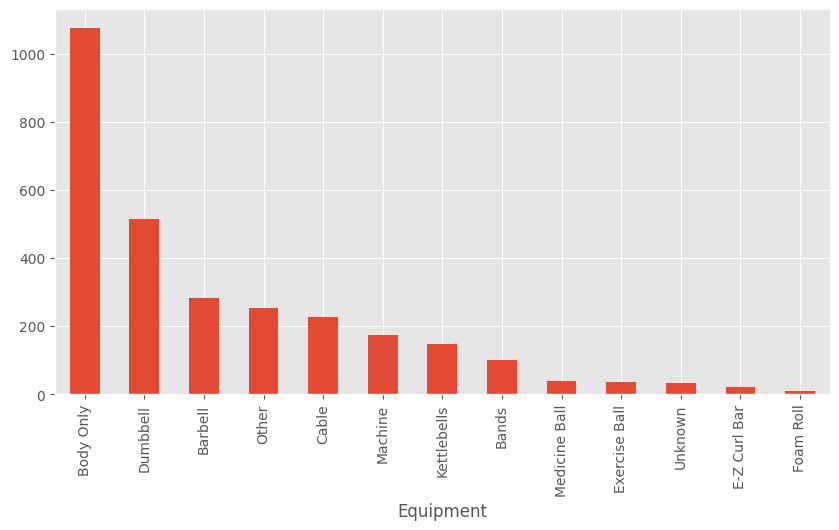

In [64]:
top_equipment = df["Equipment"].value_counts().head(15)

top_equipment.plot(
    kind="bar",
    figsize=(10,5)
)

plt.show()

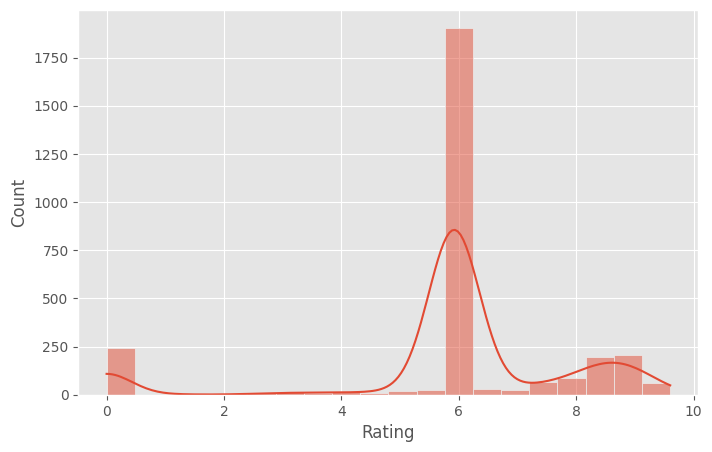

In [65]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.show()

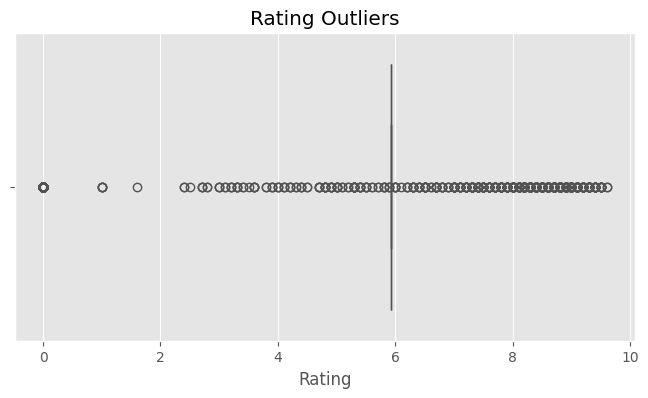

In [66]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['Rating']
)

plt.title("Rating Outliers")
plt.show()

In [67]:
Q1 = df['Rating'].quantile(0.25)

Q3 = df['Rating'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers = df[
    (df['Rating'] < lower) |
    (df['Rating'] > upper)
]

print("Outliers:",len(outliers))

Outliers: 1031


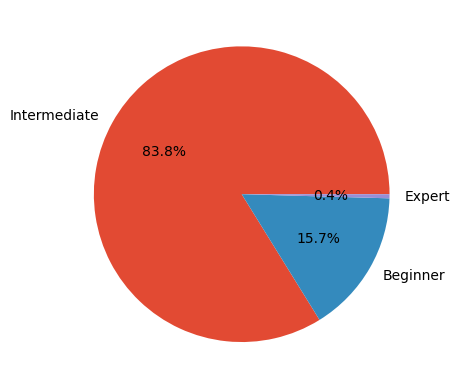

In [68]:
df['Level'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.show()

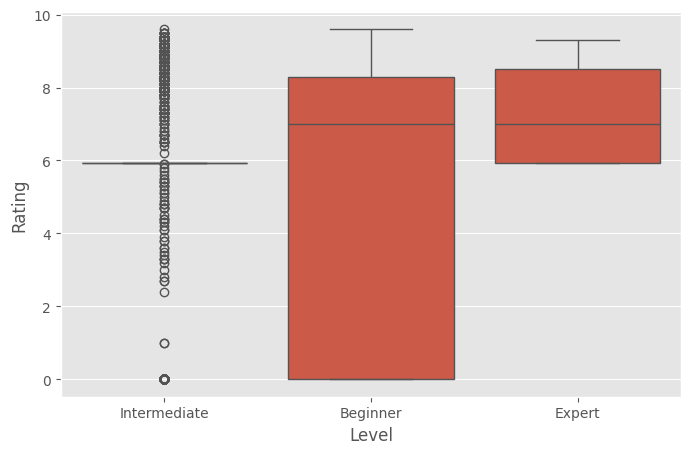

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Level',
    y='Rating',
    data=df
)

plt.show()

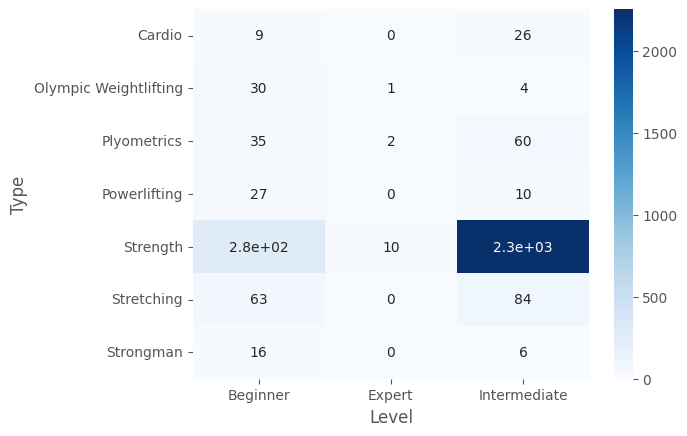

In [70]:
pivot = pd.crosstab(
    df['Type'],
    df['Level']
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='Blues'
)

plt.show()

In [71]:
from sklearn.preprocessing import LabelEncoder

temp = df.copy()

le = LabelEncoder()

temp["Type"] = le.fit_transform(temp["Type"])
temp["BodyPart"] = le.fit_transform(temp["BodyPart"])
temp["Level"] = le.fit_transform(temp["Level"])

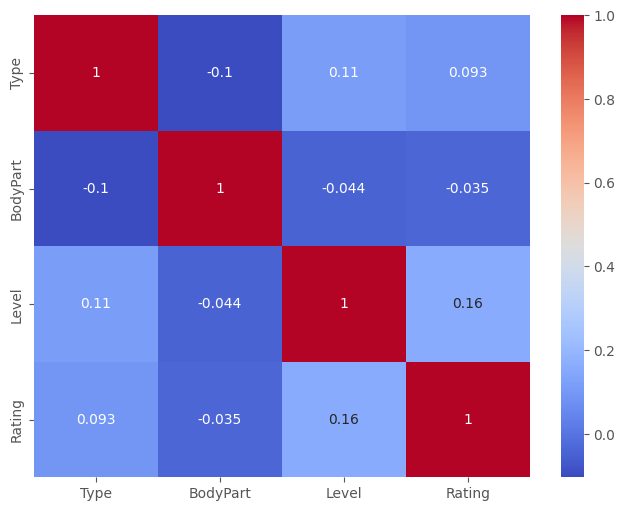

In [72]:
corr = temp[["Type","BodyPart","Level","Rating"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

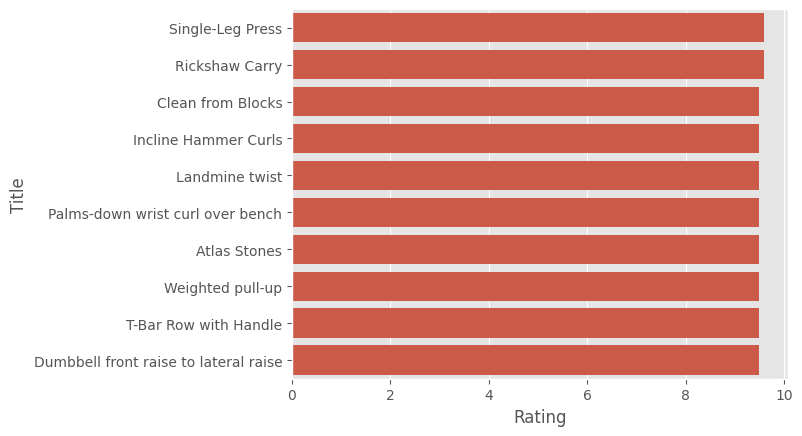

In [73]:
top10 = df.sort_values(
    'Rating',
    ascending=False
).head(10)

sns.barplot(
    x='Rating',
    y='Title',
    data=top10
)

plt.show()

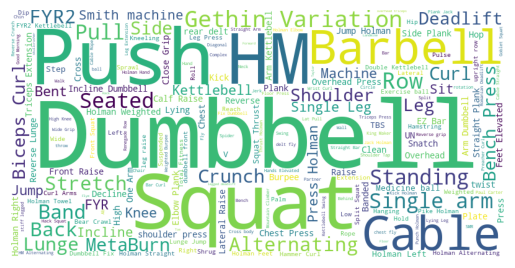

In [74]:
from wordcloud import WordCloud

text = " ".join(df['Title'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

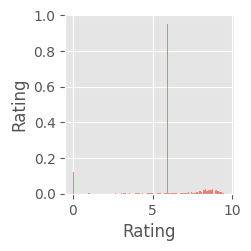

In [75]:
sns.pairplot(df[['Rating']])
plt.show()

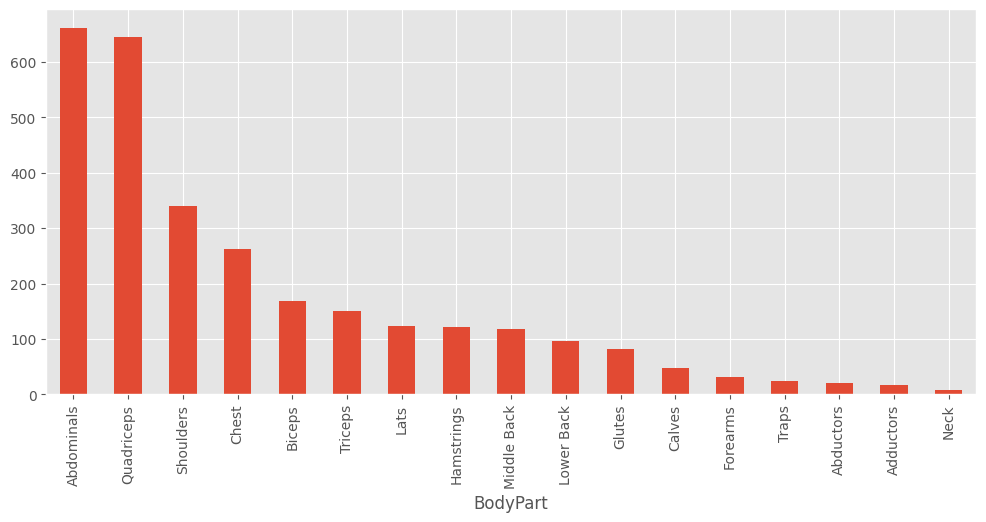

In [76]:
exercise_count = df.groupby(
    'BodyPart'
)['Title'].count().sort_values(
    ascending=False
)

exercise_count.plot(
    kind='bar',
    figsize=(12,5)
)

plt.show()

In [77]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


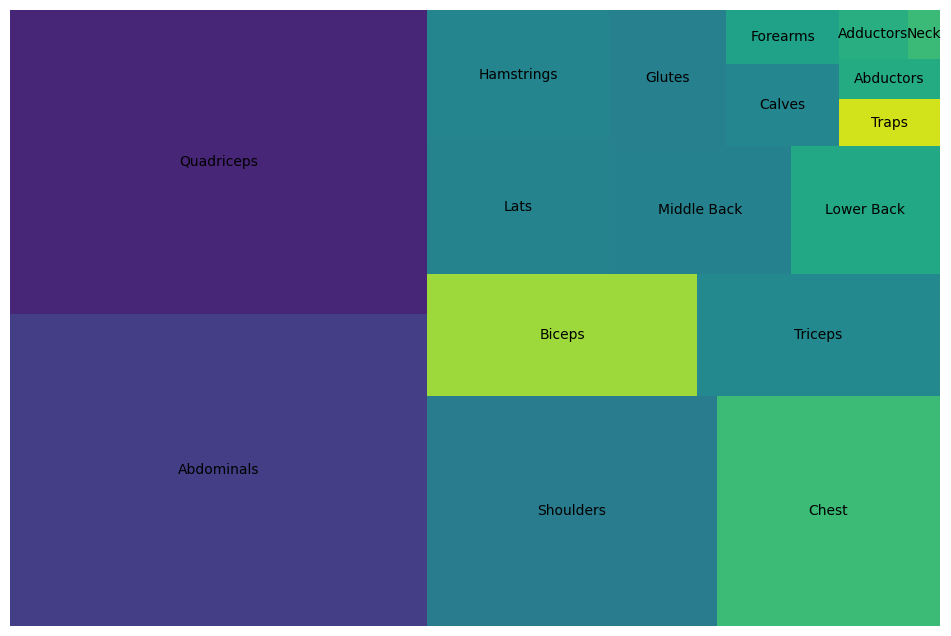

In [78]:
import squarify

sizes = df['BodyPart'].value_counts().values

labels = df['BodyPart'].value_counts().index

plt.figure(figsize=(12,8))

squarify.plot(
    sizes=sizes,
    label=labels
)

plt.axis("off")
plt.show()

In [79]:
df["features"] = (
    df["Type"] + " " +
    df["BodyPart"] + " " +
    df["Equipment"] + " " +
    df["Level"]
)

In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [81]:
df["combined"] = (
    df["Type"].astype(str) + " " +
    df["BodyPart"].astype(str) + " " +
    df["Equipment"].astype(str)
)

In [82]:
y = df["Level"]

In [83]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(
    df["combined"]
)

In [85]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [86]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [87]:
y_pred = rf.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:",accuracy)

Accuracy: 0.8647260273972602


In [89]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.72      0.33      0.45        95
           1       0.00      0.00      0.00         3
           2       0.88      0.98      0.92       486

    accuracy                           0.86       584
   macro avg       0.53      0.43      0.46       584
weighted avg       0.85      0.86      0.84       584



C:\Users\ASUS\PycharmProjects\PythonProject9\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\PycharmProjects\PythonProject9\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\PycharmProjects\PythonProject9\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

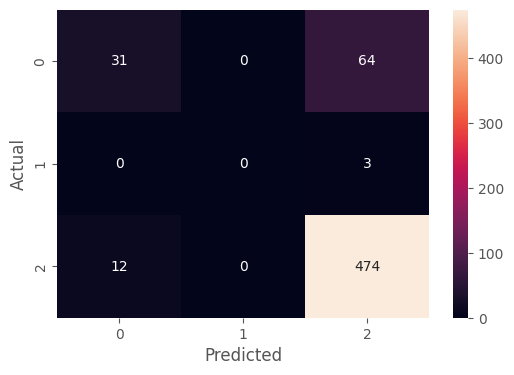

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [91]:
import pickle

pickle.dump(
    rf,
    open("difficulty_model.pkl","wb")
)

pickle.dump(
    tfidf,
    open("tfidf.pkl","wb")
)

pickle.dump(
    le,
    open("label_encoder.pkl","wb")
)

In [92]:
model = pickle.load(
    open("difficulty_model.pkl","rb")
)

tfidf = pickle.load(
    open("tfidf.pkl","rb")
)

le = pickle.load(
    open("label_encoder.pkl","rb")
)

In [93]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
!pip install streamlit


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
import streamlit as st

In [96]:
st.header(
    "Predict Exercise Difficulty"
)

type_input = st.selectbox(
    "Type",
    df["Type"].unique()
)

body_input = st.selectbox(
    "Body Part",
    df["BodyPart"].unique()
)

equipment_input = st.selectbox(
    "Equipment",
    df["Equipment"].unique()
)

2026-06-07 16:54:56.884 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.887 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.898 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.903 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.905 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.907 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [97]:
st.header(
    "Predict Exercise Difficulty"
)

type_input = st.selectbox(
    "Type",
    df["Type"].unique()
)

body_input = st.selectbox(
    "Body Part",
    df["BodyPart"].unique()
)

equipment_input = st.selectbox(
    "Equipment",
    df["Equipment"].unique()
)

2026-06-07 16:54:56.971 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.971 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.972 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.974 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.977 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.980 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.980 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:56.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [98]:
if st.button(
    "Predict Difficulty"
):

    text = (
        type_input + " " +
        body_input + " " +
        equipment_input
    )

    vector = tfidf.transform([text])

    pred = model.predict(vector)

    level = le.inverse_transform(pred)

    st.success(
        f"Predicted Level: {level[0]}"
    )

2026-06-07 16:54:57.041 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:57.044 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:57.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:57.047 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:57.048 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:54:57.049 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [110]:
if st.button(
    "Predict Difficulty"
):

    text = (
        type_input + " " +
        body_input + " " +
        equipment_input
    )

    vector = tfidf.transform([text])

    pred = model.predict(vector)

    level = le.inverse_transform(pred)

    st.success(
        f"Predicted Level: {level[0]}"
    )

2026-06-07 16:55:39.910 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:55:39.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:55:39.912 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:55:39.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:55:39.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-07 16:55:39.914 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [109]:
import pickle

pickle.dump(similarity,
            open("similarity.pkl","wb"))

pickle.dump(df,
            open("gym_data.pkl","wb"))

NameError: name 'similarity' is not defined